# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [3]:
#Write your code here
#1
import pandas as pd
raw_df = pd.read_csv("Rainfall.csv", header=None)

df = raw_df[0].str.split(",", expand=True)
df = df[df[0] != "Region"]

df.columns = ["Region", "Year", "Month", "Station", "Rainfall_mm", "RainyDays", "MaxTemp_C", "MinTemp_C", "UrbanRural"]

df["Year"] = df["Year"].astype(int)
df["Rainfall_mm"] = df["Rainfall_mm"].astype(float)
df["RainyDays"] = df["RainyDays"].astype(int)
df["MaxTemp_C"] = df["MaxTemp_C"].astype(float)
df["MinTemp_C"] = df["MinTemp_C"].astype(float)

#2
print("First 5 rows of the DataFrame: ")
print(df.head())

#3
print("\nCheck for missing values: ")
print(df.isnull().sum())

#4
print("\nSummary statistics for all numeric columns: ")
print(df.describe())

First 5 rows of the DataFrame: 
  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
1  North  2023   Jan  StationA         56.2          9       12.1        2.5   
2  North  2023   Feb  StationA         72.1         12       14.7        3.0   
3  North  2023   Jan  StationB         60.5         10       11.2        1.8   
4  South  2023   Jan  StationC         81.0         13       19.6        7.2   
5  South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
1      Urban  
2      Urban  
3      Rural  
4      Urban  
5      Urban  

Check for missing values: 
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Summary statistics for all numeric columns: 
         Year  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.0    10.000000   10.00000  10.000000  10.000000
mean   2023.0    66.160000   10.90000

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [66]:
#Write your code here
station_stats = df.groupby("Station").agg({
    "Rainfall_mm": "sum",
    "RainyDays": "mean",
    "MaxTemp_C": "mean",
    "MinTemp_C": "mean"
}).reset_index()

print(station_stats)

    Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
0  StationA        128.3       10.5      13.40       2.75
1  StationB        122.0       10.5      13.10       2.50
2  StationC        144.4       12.0      19.85       7.45
3  StationD        105.3        9.0      16.65       5.90
4  StationE        161.6       12.5      17.50       5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [68]:
#Write your code here
region_urban_stats = df.groupby(["Region", "UrbanRural"]).agg({
    "Rainfall_mm": "mean",
    "MaxTemp_C": "mean",
    "RainyDays": "mean"
}).reset_index()

print(region_urban_stats)

  Region UrbanRural  Rainfall_mm  MaxTemp_C  RainyDays
0   East      Rural        52.65      16.65        9.0
1  North      Rural        61.00      13.10       10.5
2  North      Urban        64.15      13.40       10.5
3  South      Urban        72.20      19.85       12.0
4   West      Urban        80.80      17.50       12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [70]:
#Write your code here
month_region_stats = df.groupby(["Month", "Region"]).agg({
    "Rainfall_mm": ["sum", "mean", "min", "max"]
}).reset_index()

print(month_region_stats)

  Month Region Rainfall_mm                   
                       sum   mean   min   max
0   Feb   East        59.6  59.60  59.6  59.6
1   Feb  North        72.1  72.10  72.1  72.1
2   Feb  South        63.4  63.40  63.4  63.4
3   Feb   West        84.2  84.20  84.2  84.2
4   Jan   East        45.7  45.70  45.7  45.7
5   Jan  North       116.7  58.35  56.2  60.5
6   Jan  South        81.0  81.00  81.0  81.0
7   Jan   West        77.4  77.40  77.4  77.4
8   Mar  North        61.5  61.50  61.5  61.5


4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [52]:
#Write your code here
highest_rainfall = df.loc[df["Rainfall_mm"].idxmax()]

print(highest_rainfall[["Region", "Month", "Rainfall_mm"]])

Region         West
Month           Feb
Rainfall_mm    84.2
Name: 9, dtype: object


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [56]:
#Write your code here
year_urban_stats = df.groupby(["Year", "UrbanRural"]).agg({
    "Rainfall_mm": ["mean", "min", "max"]
}).reset_index()

print(year_urban_stats)

   Year UrbanRural Rainfall_mm            
                          mean   min   max
0  2023      Rural   56.825000  45.7  61.5
1  2023      Urban   72.383333  56.2  84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [78]:
#Write your code here
df["TempRange"] = df["MaxTemp_C"] - df["MinTemp_C"]
print(df.head(3))

region_temp_range = df.groupby("Region")["TempRange"].mean().reset_index()

print()
print(region_temp_range)

  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
1  North  2023   Jan  StationA         56.2          9       12.1        2.5   
2  North  2023   Feb  StationA         72.1         12       14.7        3.0   
3  North  2023   Jan  StationB         60.5         10       11.2        1.8   

  UrbanRural  TempRange  
1      Urban        9.6  
2      Urban       11.7  
3      Rural        9.4  

  Region  TempRange
0   East     10.750
1  North     10.625
2  South     12.400
3   West     12.400


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



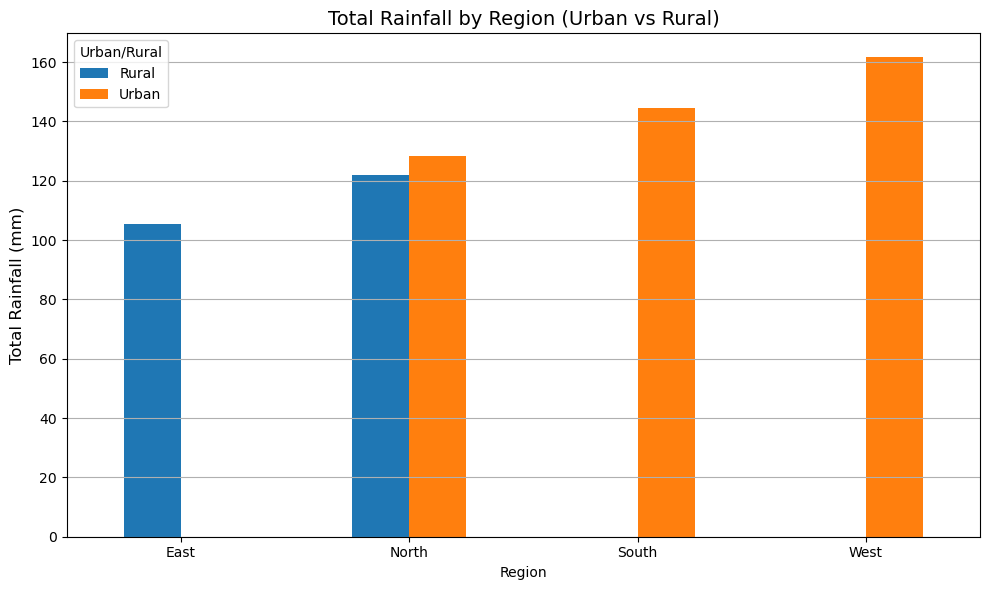

In [95]:
#Write your code here
import matplotlib.pyplot as plt

rain_totals = df.groupby(["Region", "UrbanRural"])["Rainfall_mm"].sum().unstack()

rain_totals.plot(kind="bar", stacked=False, figsize=(10, 6))
plt.title("Total Rainfall by Region (Urban vs Rural)", fontsize=14)
plt.ylabel("Total Rainfall (mm)", fontsize=12)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.legend(title="Urban/Rural")
plt.tight_layout()
plt.savefig("barchart_total_rainfall_by_region.png")
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



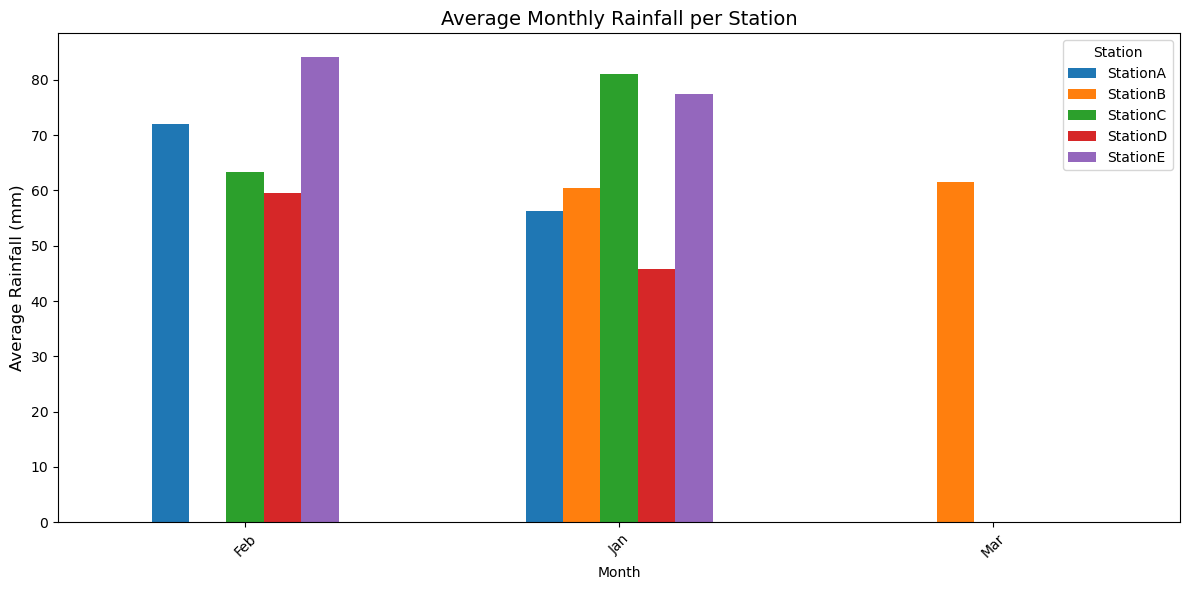

In [93]:
#Write your code here
monthly_rainfall = df.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

monthly_rainfall.plot(kind="bar", figsize=(12, 6))
plt.title("Average Monthly Rainfall per Station", fontsize=14)
plt.ylabel("Average Rainfall (mm)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Station")
plt.tight_layout()
plt.savefig("barchart_mean_rainfall_per_station.png")
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



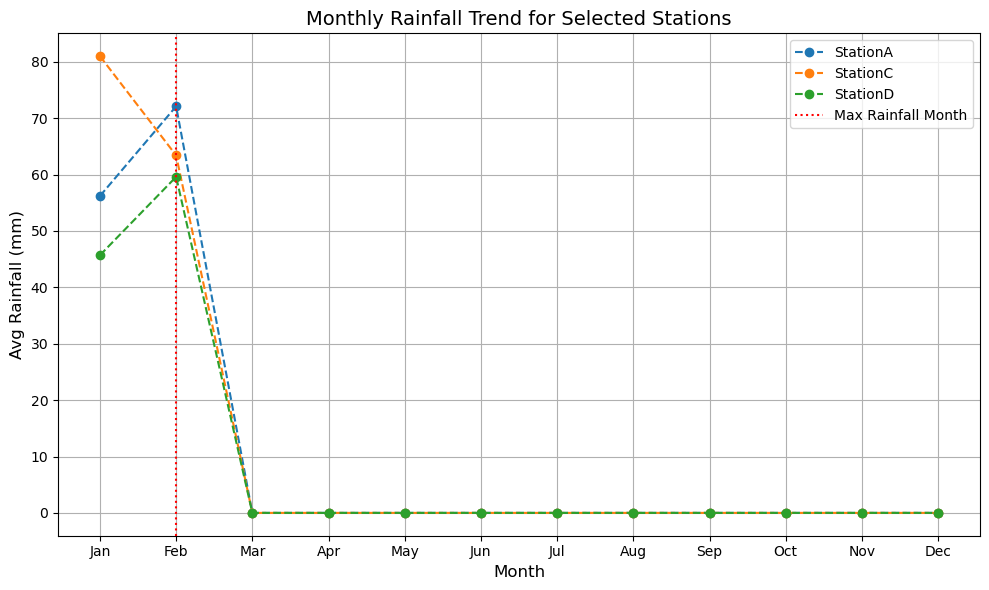

In [109]:
#Write your code here
# filter 3 stations
stations = ["StationA", "StationC", "StationD"]
filtered_data = df[df["Station"].isin(stations)]

monthly_avg = filtered_data.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

# Reorder columns
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_avg = monthly_avg.reindex(month_order, fill_value=0)

plt.figure(figsize=(10, 6))
for station in stations:
    plt.plot(monthly_avg.index, monthly_avg[station], marker='o', linestyle='--', label=station)

# Highlight month with max rainfall
max_month = monthly_avg.sum(axis=1).idxmax()
plt.axvline(x=max_month, color='red', linestyle=':', label='Max Rainfall Month')

plt.title("Monthly Rainfall Trend for Selected Stations", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Avg Rainfall (mm)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("lineplot_monthly_rainfall_trend_by_stations.png")
plt.show()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



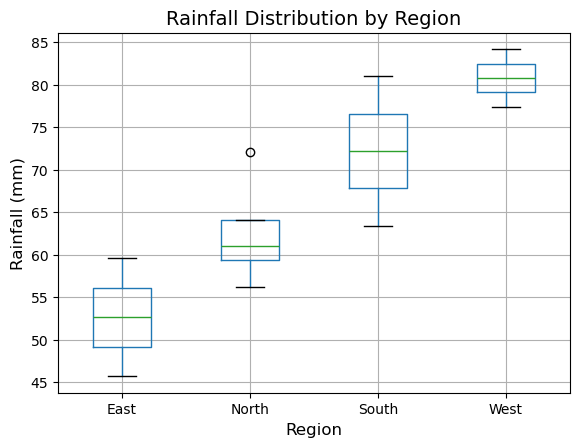

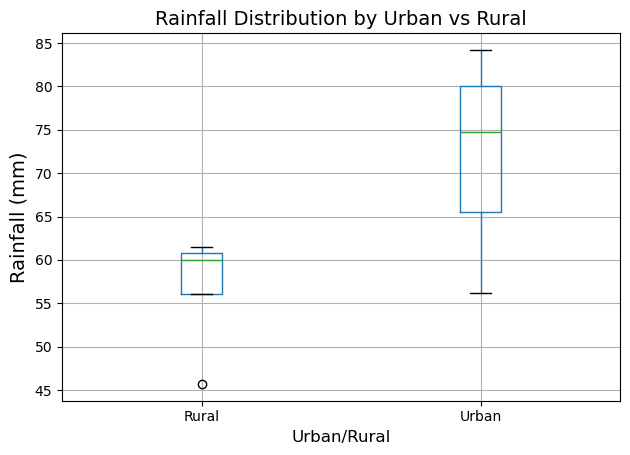

In [107]:
#Write your code here
df.boxplot(column="Rainfall_mm", by="Region")
plt.title("Rainfall Distribution by Region", fontsize=14)
plt.suptitle("")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.savefig("boxplot_rainfall_by_region.png")

df.boxplot(column="Rainfall_mm", by="UrbanRural")
plt.title("Rainfall Distribution by Urban vs Rural", fontsize=14)
plt.suptitle("")
plt.xlabel("Urban/Rural", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=14)
plt.savefig("boxplot_rainfall_by_urbanrural.png")

plt.grid(True)
plt.tight_layout()
plt.show()

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



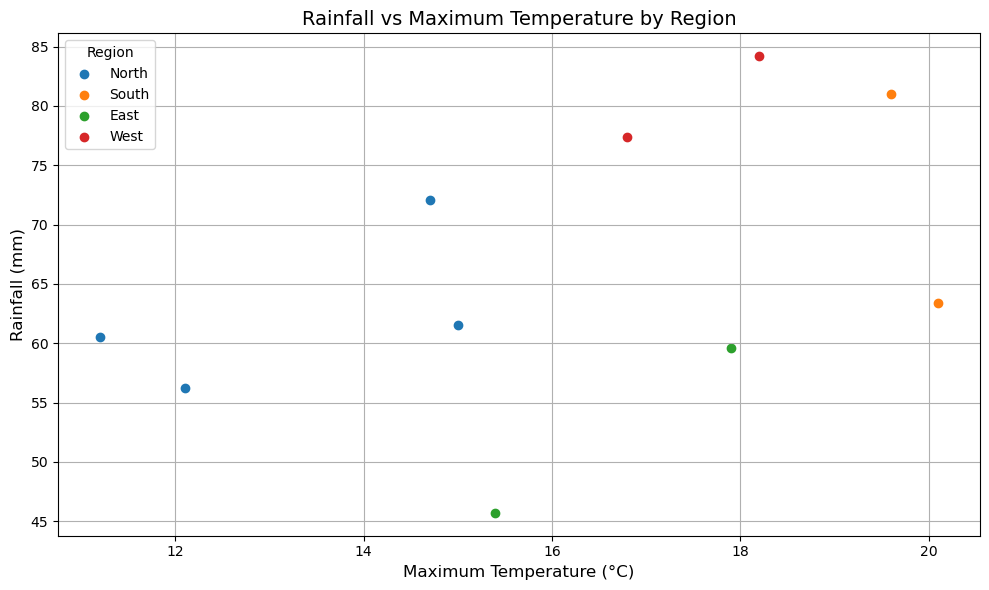

In [79]:
#Write your code here
import numpy as np

# Unique regions
regions = df["Region"].unique()

plt.figure(figsize=(10, 6))

# Plot each region
for i, region in enumerate(regions):
    subset = df[df["Region"] == region]
    plt.scatter(subset["MaxTemp_C"], subset["Rainfall_mm"], label=region)

plt.xlabel("Maximum Temperature (°C)", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.title("Rainfall vs Maximum Temperature by Region", fontsize=14)
plt.legend(title="Region")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_rainfall_maxtemp_region.png")
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



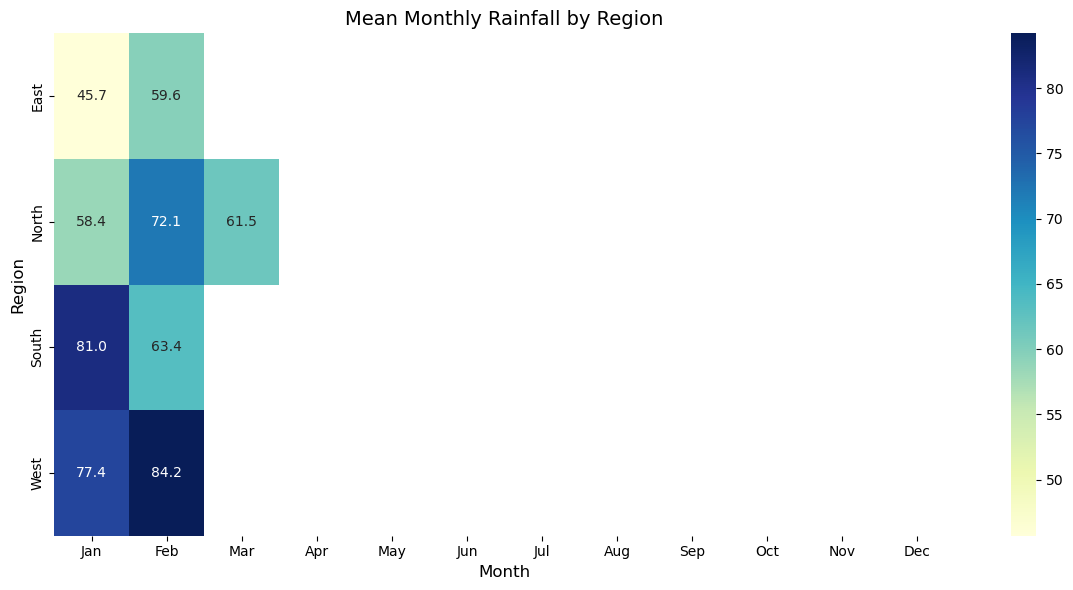

In [81]:
#Write your code here
import seaborn as sns

heatmap_df = df.groupby(["Region", "Month"])["Rainfall_mm"].mean().unstack()

# Reorder columns
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_df = heatmap_df.reindex(columns=month_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True)

plt.title("Mean Monthly Rainfall by Region", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.tight_layout()
plt.savefig("heatmap_mean_rainfall_by_region.png")
plt.show()

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [18]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


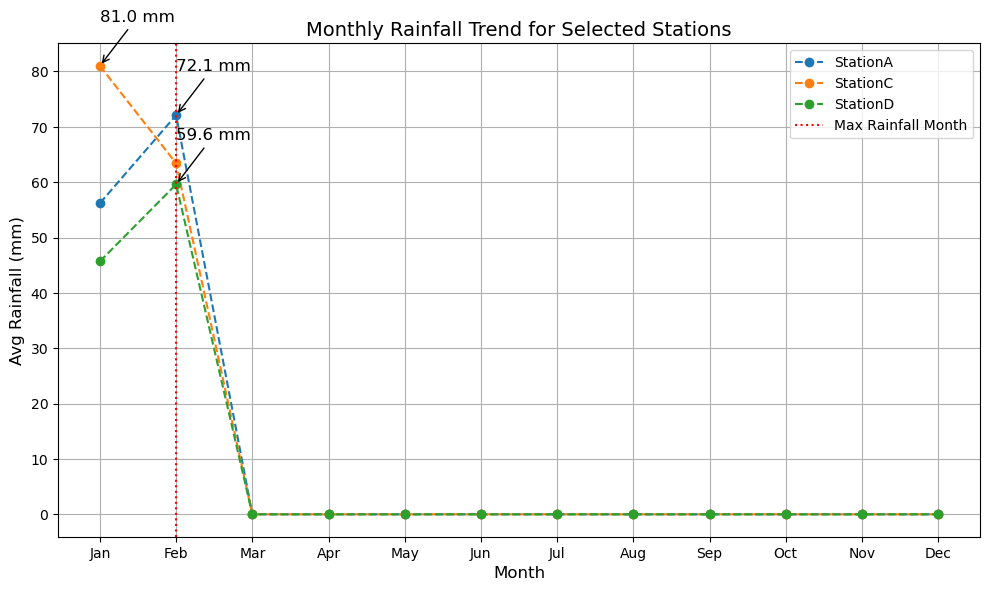

In [125]:
# filter 3 stations
stations = ["StationA", "StationC", "StationD"]
filtered_data = df[df["Station"].isin(stations)]

monthly_avg = filtered_data.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

# Reorder columns
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_avg = monthly_avg.reindex(month_order, fill_value=0)

plt.figure(figsize=(10, 6))
for station in stations:
    plt.plot(monthly_avg.index, monthly_avg[station], marker='o', linestyle='--', label=station)
    # Annotate max point per station
    max_rain = monthly_avg[station].max()
    max_month = monthly_avg[station].idxmax()
    plt.annotate(f"{max_rain:.1f} mm",
                 xy=(max_month, max_rain),
                 xytext=(max_month, max_rain + 8),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=12)

# Highlight month with max rainfall
max_month = monthly_avg.sum(axis=1).idxmax()
plt.axvline(x=max_month, color='red', linestyle=':', label='Max Rainfall Month')

plt.title("Monthly Rainfall Trend for Selected Stations", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Avg Rainfall (mm)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


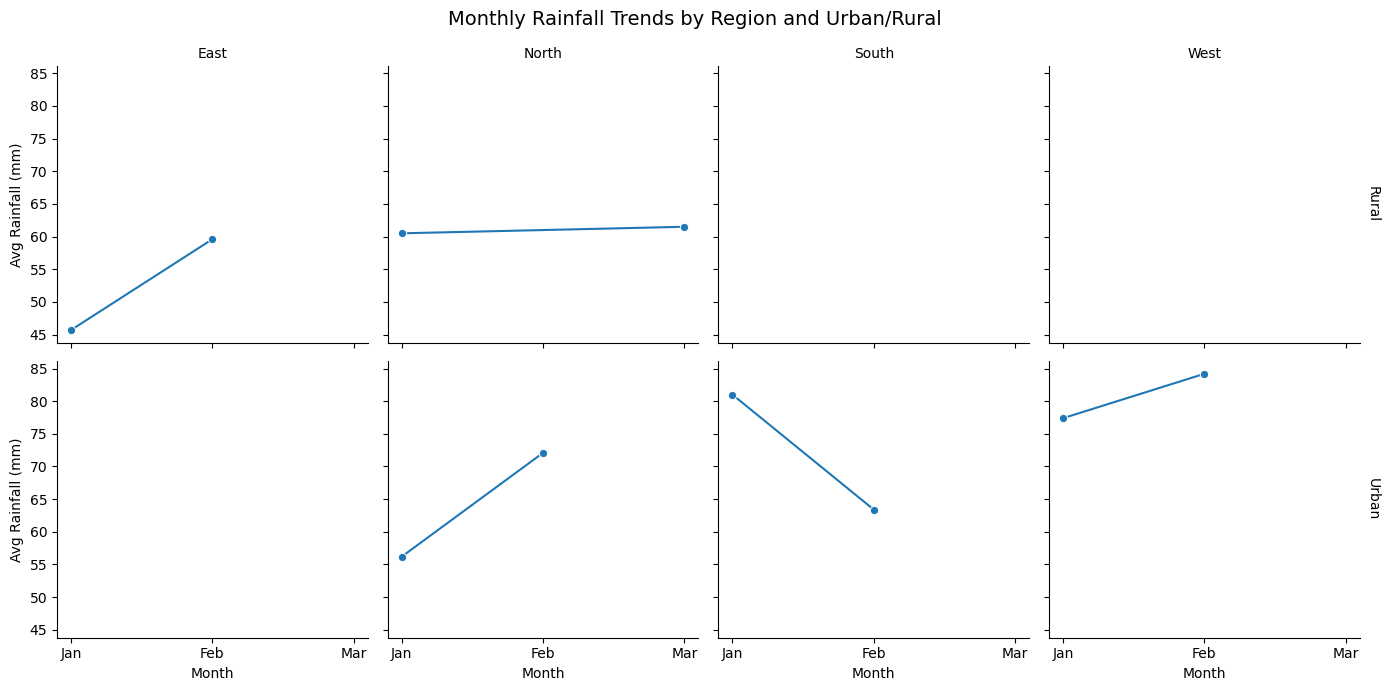

In [133]:
# Average monthly rainfall by Region & UrbanRural
facet_df = df.groupby(["Month", "Region", "UrbanRural"])["Rainfall_mm"].mean().reset_index()

# Convert Month to ordered category
facet_df["Month"] = pd.Categorical(facet_df["Month"], categories=[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], ordered=True)

# Facet plot
f = sns.FacetGrid(facet_df, col="Region", row="UrbanRural", margin_titles=True, height=3.5)
f.map_dataframe(sns.lineplot, x="Month", y="Rainfall_mm", marker="o")
f.set_axis_labels("Month", "Avg Rainfall (mm)")
f.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.subplots_adjust(top=0.9)
f.fig.suptitle("Monthly Rainfall Trends by Region and Urban/Rural", fontsize=14)
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

Through the analysis of the rainfall dataset, several key patterns and trends were identified:

- **Regional Patterns**: The **West region** recorded the **highest single-month rainfall** (84.2 mm in February), while the **East region** generally had lower rainfall totals, particularly in January (45.7 mm).

- **Station Performance**: Among all stations, **StationE** recorded the **highest total rainfall** (161.6 mm), while **StationD** had the **lowest** (105.3 mm)

- **Monthly Trends**: February was observed as the **wettest month overall**, with high rainfall across multiple regions, particularly the West and North.

- **Urban vs Rural Differences**: Boxplots illustrated that **Urban areas** experienced **wider rainfall distribution**, while **Rural areas** tended to have lower median rainfall and less variation.

These insights can support weather forecasting, resource planning, and climate research by identifying regions and stations with extreme or stable rainfall behaviors.